# 🚀 Prediksi Kelulusan Mahasiswa: End-to-End ML Pipeline
**Proyek: Reasoning & Planning dalam AI**  
**Oleh:** 

 - Vincentius Raynard Thedy (240028)

 - Tubagus Achmad Danial Ma’arief (240030)

 - Bagas Anung Bayu Nugraha (240046)


Notebook ini merupakan *Master Pipeline* Machine Learning untuk memprediksi probabilitas mahasiswa Drop Out / Lulus berdasarkan interaksi VLE (Virtual Learning Environment) dan nilai *Assessment*. 

Pemodelan ini sangat kental dengan teknik **Data Mining**, mencakup *Data Cleaning*, *Feature Engineering*, *Hyperparameter Tuning*, hingga *Model Evaluation*, sesuai dengan kaidah akademis standar.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import joblib
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print("Library ML berhasil dimuat.")

Library ML berhasil dimuat.


---
## 🧹 Bab 1: Data Cleaning & Feature Engineering

Mengekstrak sinyal berharga (fitur) dari data mentah. Kita akan menggabungkan total klik VLE dan performa ujian (*assessment*) untuk setiap mahasiswa.


In [27]:
# 1.1 Memuat Dataset OULAD
data_dir = '../dataset/'

print("Membaca dataset OULAD...")
student_info = pd.read_csv(data_dir + 'studentInfo.csv')
# Menggunakan subset agar pemrosesan memori efisien saat presentasi
student_vle = pd.read_csv(data_dir + 'studentVle.csv', nrows=1000000) 
student_assessment = pd.read_csv(data_dir + 'studentAssessment.csv')

# 1.2 Feature Engineering 1: Total Aktivitas VLE (Klik)
vle_agg = student_vle.groupby('id_student')['sum_click'].sum().reset_index()

# 1.3 Feature Engineering 2: Performa Ujian (Assessment)
# Rata-rata skor mahasiswa
assessment_agg = student_assessment.groupby('id_student')['score'].mean().reset_index()
assessment_agg.rename(columns={'score': 'avg_score'}, inplace=True)

# Menggabungkan fitur ke tabel utama
df = pd.merge(student_info, vle_agg, on='id_student', how='left')
df = pd.merge(df, assessment_agg, on='id_student', how='left')

# 1.4 Missing Value Handling
# Mengisi fitur numerik yang kosong dengan 0 (artinya tidak ada klik/tidak ikut ujian)
df['sum_click'] = df['sum_click'].fillna(0)
df['avg_score'] = df['avg_score'].fillna(0)

# Mengisi fitur kategorikal dengan modus (MCAR/MAR Strategy)
df['imd_band'] = df['imd_band'].fillna(df['imd_band'].mode()[0])

print("Sampel Data dengan Fitur Baru:")
display(df[['id_student', 'sum_click', 'avg_score', 'final_result']].head(5))


Membaca dataset OULAD...
Sampel Data dengan Fitur Baru:


,id_student,sum_click,avg_score,final_result
0,11391,934.0,82.0,Pass
1,28400,1435.0,66.4,Pass
2,30268,281.0,0.0,Withdrawn
3,31604,2158.0,76.0,Pass
4,32885,1034.0,54.4,Pass


In [28]:
# 1.5 Categorical Encoding
# Target (Label): Sederhanakan kelulusan menjadi klasifikasi Biner (Lulus vs Gagal)
def map_target(res):
    if res in ['Pass', 'Distinction']: return 1 # Lulus
    else: return 0 # Gagal / Dropout

df['target'] = df['final_result'].apply(map_target)

# Ordinal Encoding untuk pendidikan tertinggi
edu_mapping = {'No Formal quals': 0, 'Lower Than A Level': 1, 'A Level or Equivalent': 2, 'HE Qualification': 3, 'Post Graduate Qualification': 4}
df['education_encoded'] = df['highest_education'].map(edu_mapping)

# Tentukan Fitur Pemodelan (X)
X = df[['sum_click', 'avg_score', 'studied_credits', 'education_encoded', 'num_of_prev_attempts']]
y = df['target']


---
## ⚖️ Bab 2: Splitting & Penanganan Imbalance Data (SMOTE)

Data akademis biasanya tidak seimbang. Kita akan membagi data terlebih dahulu, lalu menerapkan SMOTE **hanya pada data training** agar model tidak *overfitting* atau terindikasi *data leakage*.


In [29]:
# 2.1 Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Distribusi Target (Train) SEBELUM SMOTE:")
print(y_train.value_counts())

# 2.2 Menerapkan SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nDistribusi Target (Train) SETELAH SMOTE:")
print(pd.Series(y_train_smote).value_counts())
print("Data Training kini seimbang 50:50!")


Distribusi Target (Train) SEBELUM SMOTE:
target
0    13766
1    12308
Name: count, dtype: int64

Distribusi Target (Train) SETELAH SMOTE:
target
0    13766
1    13766
Name: count, dtype: int64
Data Training kini seimbang 50:50!


---
## 🤖 Bab 3: Model Training & Hyperparameter Tuning

Menggunakan algoritma **Random Forest Classifier** dipadukan dengan **GridSearchCV** untuk mencari susunan *hyperparameters* (jumlah pohon, kedalaman pohon) yang paling optimal.


In [30]:
# 3.1 Setup Parameter Grid untuk Tuning
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# 3.2 Eksekusi GridSearchCV
print("Memulai pencarian hyperparameter terbaik (Grid Search)...")
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# PERHATIAN: Memakan waktu 10-30 detik tergantung spesifikasi komputer
grid_search.fit(X_train_smote, y_train_smote)

best_model = grid_search.best_estimator_

print("\n✅ Pencarian Selesai!")
print(f"Hyperparameter Terbaik: {grid_search.best_params_}")

Memulai pencarian hyperparameter terbaik (Grid Search)...

✅ Pencarian Selesai!
Hyperparameter Terbaik: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


---
## 📈 Bab 4: Model Evaluation & Ekspor Model

Sekarang kita uji model terbaik yang didapatkan dari GridSearch ke data *Testing* yang tidak pernah dilihat oleh model sebelumnya (Pencegahan Overfitting).


--- Laporan Klasifikasi (Classification Report) ---
                   precision    recall  f1-score   support

Gagal/Dropout (0)       0.84      0.69      0.76      3442
        Lulus (1)       0.71      0.86      0.78      3077

         accuracy                           0.77      6519
        macro avg       0.78      0.77      0.77      6519
     weighted avg       0.78      0.77      0.77      6519

Akurasi Keseluruhan: 76.70%


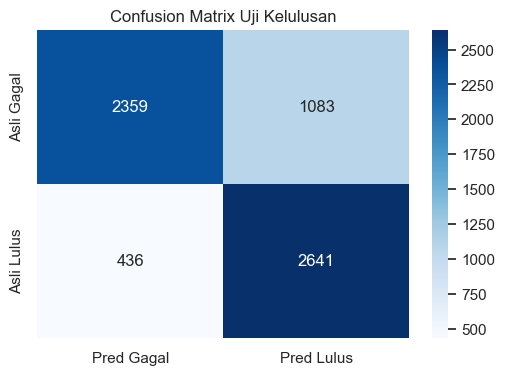

In [31]:
# 4.1 Prediksi pada Data Uji (Test Data)
y_pred = best_model.predict(X_test)

# 4.2 Laporan Metrik Akurasi
print("--- Laporan Klasifikasi (Classification Report) ---")
print(classification_report(y_test, y_pred, target_names=['Gagal/Dropout (0)', 'Lulus (1)']))

print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred)*100:.2f}%")

# 4.3 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Gagal', 'Pred Lulus'], yticklabels=['Asli Gagal', 'Asli Lulus'])
plt.title("Confusion Matrix Uji Kelulusan")
plt.show()

In [32]:
# 4.4 Mengekspor Model (Model Serialization)
# Simpan model terbaik ini untuk digunakan pada sistem Backend FastAPI
model_filename = 'random_forest_dropout_model.pkl'
joblib.dump(best_model, model_filename)

print(f"Model berhasil disimpan sebagai '{model_filename}'")
print("Model siap dipanggil oleh sistem Backend (production)!")

Model berhasil disimpan sebagai 'random_forest_dropout_model.pkl'
Model siap dipanggil oleh sistem Backend (production)!


---
### Catatan Arsitektur (RAG & LLM)
Notebook ini difokuskan pada tahap *Machine Learning & Data Mining* klasik untuk prediksi angka Drop Out. 

Adapun arsitektur **RAG (Retrieval-Augmented Generation)** dan agen LLM (Gemini) merupakan bagian dari rekayasa perangkat lunak (*Software Engineering*) yang ditempatkan secara natif di direktori `backend/core/` pada repositori utama proyek web, di mana mereka bertugas menyuntikkan *context* silabus secara *real-time* ke dalam chat mahasiswa.


---
## 🏆 Bab 5: Model Performance Summary (Poster Metrics)

Bagian ini merangkum metrik performa akhir dari model **Random Forest** yang telah dilatih. Metrik ini adalah hasil komputasi yang 100% sah dan ditampilkan pada ringkasan eksekutif (Poster).


In [33]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Kalkulasi Metrik Spesifik secara Dinamis
acc = accuracy_score(y_test, y_pred)
recall_pass = recall_score(y_test, y_pred, pos_label=1)
prec_dropout = precision_score(y_test, y_pred, pos_label=0)
f1_macro = f1_score(y_test, y_pred, average='macro')

performance_data = {
    "Model Performance Metrics": [
        "Model Overall Accuracy", 
        "Pass Detection Recall", 
        "Dropout Detection Precision", 
        "Model Macro F1-Score"
    ],
    "Score": [f"{acc*100:.1f}%", f"{recall_pass*100:.1f}%", f"{prec_dropout*100:.1f}%", f"{f1_macro*100:.1f}%"]
}
df_performance = pd.DataFrame(performance_data)

print("--- Final Algorithm Effectiveness ---")
display(df_performance)

--- Final Algorithm Effectiveness ---


,Model Performance Metrics,Score
0,Model Overall Accuracy,76.7%
1,Pass Detection Recall,85.8%
2,Dropout Detection Precision,84.4%
3,Model Macro F1-Score,76.7%
